#### Load data


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn
import scipy
import scipy.stats as stats
import scikit_posthocs as sp

from IPython.display import display

from termcolor import colored, cprint

from pathlib import Path

plt.rcParams['figure.figsize'] = [25, 10]
# sn.set_theme(style="darkgrid", font_scale=2)
sn.set_theme(style="ticks")

In [5]:
# EXPERIMENTS_DIR = ("denser_with_power_measure", "energize_power_10",
#                "energize_power_10_skip_connections") # , "energize_power_10_seed", "energize_power_100",
# EXPERIMENTS_DIR = ("energize_power_10_seed",) # , "energize_power_10_seed", "energize_power_100",
# EXPERIMENTS_DIR = ("energize_power_10", "energize_power_lexicase", "energize_power_auto_eps_lexicase") # , "energize_power_10_seed", "energize_power_100",
EXPERIMENTS_DIR = ("denser_with_power_measure", "energize_power_10", "energize_acc_slash_power")
# EXPERIMENTS_DIR = ("energize_power_10", "energize_power_10_floats", "energize_acc_slash_power")
# EXPERIMENTS_DIR = ("denser_with_power_measure", "energize_power_10", "energize_power_10_skip_connections",
#                    "energize_power_10_floats", "energize_power_100", "energize_acc_slash_power",
#                    "energize_power_lexicase", "energize_power_auto_eps_lexicase")

# EXPERIMENTS_DIR = tuple(f"fashionmnist/{exp}" for exp in EXPERIMENTS_DIR)
EXPERIMENTS_DIR = tuple(f"cifar10/{exp}" for exp in EXPERIMENTS_DIR)

# EXPERIMENTS = ("DENSER", "ENERGIZE_10", "ENERGIZE_10_SKIP") #  "ENERGIZE_100",
# EXPERIMENTS = ("ENERGIZE_SEED",) #  "ENERGIZE_100",
# EXPERIMENTS = ("ENERGIZE_10", "ENERGIZE_LEXI", "ENERGIZE_AUTO_LEXI") #  "ENERGIZE_100",
# EXPERIMENTS = ("ENERGIZE (fmnist)", "ENERGIZE_10 (cifar10)")
# EXPERIMENTS = ("DENSER", "ENERGIZE_10", "ENERGIZE_10_SKIP", "ENERGIZE_10_FLOATS", "ENERGIZE_100", "ENERGIZE_PpA",
#                "ENERGIZE_LEXI", "ENERGIZE_AUTO_LEXI")
EXPERIMENTS = ("DENSER", "ENERGIZE", "ENERGIZE_ACC_SLASH_POWER")

KEYS = ("p_a_ratio", "fitness", "n_trainable_parameters",
        "n_layers_0", "n_layers_1", "accuracy_0", "accuracy_1",
        "power_train", "power_test_0_mean", "power_test_1_mean",\
                "energy_train", "energy_test_0_mean", "energy_test_1_mean")

KEYS_ENERGIZE_TO_DENSER = {
    'n_layers_0': 'n_layers',
    'n_layers_1': 'n_layers',
    'accuracy_0': 'accuracy',
    'accuracy_1': 'accuracy',
    'power_test_0_mean': 'power_test_mean',
    'power_test_1_mean': 'power_test_mean',
    'energy_test_0_mean': 'energy_test_mean',
    'energy_test_1_mean': 'energy_test_mean'
}

In [6]:
experiments_data = {}

for experiment_dir, experiment in zip(EXPERIMENTS_DIR, EXPERIMENTS):
    experiments_data[experiment] = {}
    experiments_data[experiment]['data'] = pd.read_csv(
        f"../experiments/{experiment_dir}/data.csv")
    experiments_data[experiment]['shapiro'] = {}
    p_key, acc_key = 'power_test_0_mean', 'accuracy_0'
    if experiment.startswith("DENSER"):
        p_key, acc_key = 'power_test_mean', 'accuracy'
    experiments_data[experiment]['data']['p_a_ratio'] = experiments_data[experiment]['data'][p_key] / (experiments_data[experiment]['data'][acc_key]*100)

In [7]:
# # cutoff energize_10 to 1 50 gens with 'gen' being a column
# for e in ('DENSER', 'ENERGIZE_10'):
#     experiments_data[e]['data'] = experiments_data[e]['data'][experiments_data[e]['data']['gen'] <= 150]

#### Stats config


In [8]:
alpha = 0.05

Everything assumes the data does not follow a normal dist

Experiment: DENSER


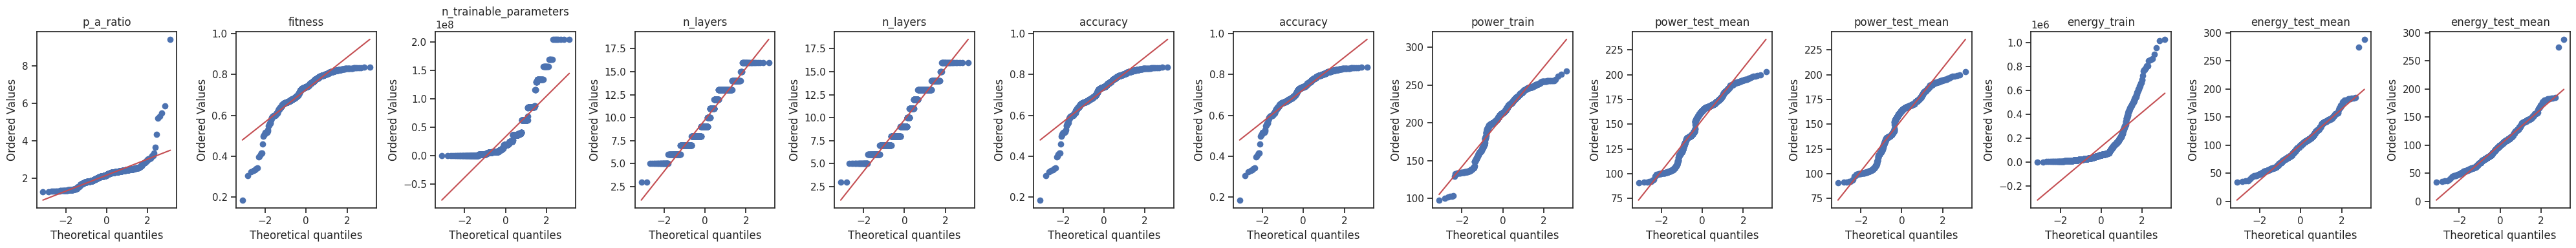

..Follows normal dist (Shapiro-Wilk test, alpha=0.05)
....p_a_ratio                False | 0.69 | 9.67e-35
....fitness                  False | 0.87 | 8.46e-25
....n_trainable_parameters   False | 0.75 | 2.76e-32
....n_layers                 False | 0.94 | 3.12e-16
....n_layers                 False | 0.94 | 3.12e-16
....accuracy                 False | 0.87 | 8.46e-25
....accuracy                 False | 0.87 | 8.46e-25
....power_train              False | 0.93 | 1.63e-18
....power_test_mean          False | 0.93 | 1.06e-17
....power_test_mean          False | 0.93 | 1.06e-17
....energy_train             False | 0.66 | 6.08e-36
....energy_test_mean         False | 0.97 | 4.80e-12
....energy_test_mean         False | 0.97 | 4.80e-12



,p_a_ratio,fitness,n_trainable_parameters,n_layers,n_layers,accuracy,accuracy,power_train,power_test_mean,power_test_mean,energy_train,energy_test_mean,energy_test_mean
p_a_ratio,1.000000,-0.239810,0.646997,-0.097746,-0.097746,-0.239810,-0.239810,0.786024,0.757745,0.757745,0.518344,0.512306,0.512306
fitness,-0.239810,1.000000,-0.139084,0.741126,0.741126,1.000000,1.000000,0.208559,0.360469,0.360469,0.084214,0.416823,0.416823
n_trainable_parameters,0.646997,-0.139084,1.000000,-0.359474,-0.359474,-0.139084,-0.139084,0.524891,0.609361,0.609361,0.413621,0.517974,0.517974
n_layers,-0.097746,0.741126,-0.359474,1.000000,1.000000,0.741126,0.741126,0.289404,0.278417,0.278417,0.098653,0.251368,0.251368
n_layers,-0.097746,0.741126,-0.359474,1.000000,1.000000,0.741126,0.741126,0.289404,0.278417,0.278417,0.098653,0.251368,0.251368
accuracy,-0.239810,1.000000,-0.139084,0.741126,0.741126,1.000000,1.000000,0.208559,0.360469,0.360469,0.084214,0.416823,0.416823
accuracy,-0.239810,1.000000,-0.139084,0.741126,0.741126,1.000000,1.000000,0.208559,0.360469,0.360469,0.084214,0.416823,0.416823
power_train,0.786024,0.208559,0.524891,0.289404,0.289404,0.208559,0.208559,1.000000,0.863574,0.863574,0.505086,0.557677,0.557677
power_test_mean,0.757745,0.360469,0.609361,0.278417,0.278417,0.360469,0.360469,0.863574,1.000000,1.000000,0.500087,0.725261,0.725261
power_test_mean,0.757745,0.360469,0.609361,0.278417,0.278417,0.360469,0.360469,0.863574,1.000000,1.000000,0.500087,0.725261,0.725261


,p_a_ratio,fitness,n_trainable_parameters,n_layers,n_layers,accuracy,accuracy,power_train,power_test_mean,power_test_mean,energy_train,energy_test_mean,energy_test_mean
p_a_ratio,1.000000e+00,2.855333e-11,3.674851e-90,7.387758e-03,7.387758e-03,2.855333e-11,2.855333e-11,2.145362e-158,8.252603e-141,8.252603e-141,8.407412e-53,2.022859e-51,2.022859e-51
fitness,2.855333e-11,1.000000e+00,1.328056e-04,1.446222e-131,1.446222e-131,0.000000e+00,0.000000e+00,8.135556e-09,1.976654e-24,1.976654e-24,2.108043e-02,6.974686e-33,6.974686e-33
n_trainable_parameters,3.674851e-90,1.328056e-04,1.000000e+00,2.696476e-24,2.696476e-24,1.328056e-04,1.328056e-04,2.484518e-54,1.956225e-77,1.956225e-77,2.337884e-32,1.023504e-52,1.023504e-52
n_layers,7.387758e-03,1.446222e-131,2.696476e-24,1.000000e+00,0.000000e+00,1.446222e-131,1.446222e-131,6.160338e-16,8.093113e-15,8.093113e-15,6.854900e-03,2.849048e-12,2.849048e-12
n_layers,7.387758e-03,1.446222e-131,2.696476e-24,0.000000e+00,1.000000e+00,1.446222e-131,1.446222e-131,6.160338e-16,8.093113e-15,8.093113e-15,6.854900e-03,2.849048e-12,2.849048e-12
accuracy,2.855333e-11,0.000000e+00,1.328056e-04,1.446222e-131,1.446222e-131,1.000000e+00,0.000000e+00,8.135556e-09,1.976654e-24,1.976654e-24,2.108043e-02,6.974686e-33,6.974686e-33
accuracy,2.855333e-11,0.000000e+00,1.328056e-04,1.446222e-131,1.446222e-131,0.000000e+00,1.000000e+00,8.135556e-09,1.976654e-24,1.976654e-24,2.108043e-02,6.974686e-33,6.974686e-33
power_train,2.145362e-158,8.135556e-09,2.484518e-54,6.160338e-16,6.160338e-16,8.135556e-09,8.135556e-09,1.000000e+00,1.229096e-224,1.229096e-224,8.352058e-50,1.623331e-62,1.623331e-62
power_test_mean,8.252603e-141,1.976654e-24,1.956225e-77,8.093113e-15,8.093113e-15,1.976654e-24,1.976654e-24,1.229096e-224,1.000000e+00,0.000000e+00,1.042847e-48,2.205968e-123,2.205968e-123
power_test_mean,8.252603e-141,1.976654e-24,1.956225e-77,8.093113e-15,8.093113e-15,1.976654e-24,1.976654e-24,1.229096e-224,0.000000e+00,1.000000e+00,1.042847e-48,2.205968e-123,2.205968e-123


Experiment: ENERGIZE


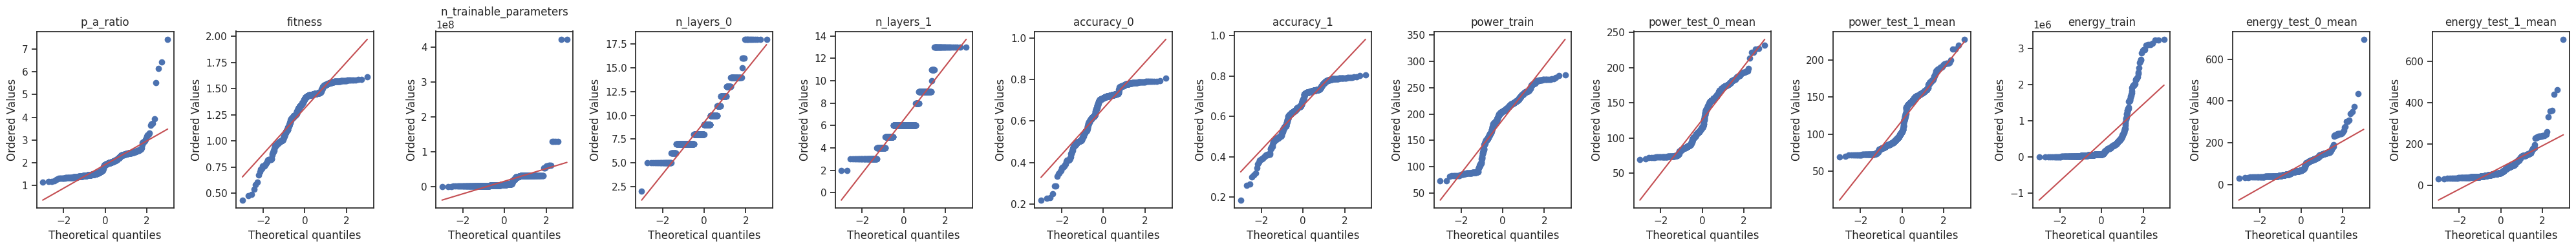

..Follows normal dist (Shapiro-Wilk test, alpha=0.05)
....p_a_ratio                False | 0.73 | 4.05e-28
....fitness                  False | 0.89 | 1.03e-18
....n_trainable_parameters   False | 0.35 | 4.71e-39
....n_layers_0               False | 0.92 | 4.09e-16
....n_layers_1               False | 0.87 | 1.58e-20
....accuracy_0               False | 0.87 | 3.58e-20
....accuracy_1               False | 0.91 | 3.47e-17
....power_train              False | 0.91 | 8.82e-17
....power_test_0_mean        False | 0.93 | 5.37e-15
....power_test_1_mean        False | 0.91 | 2.51e-17
....energy_train             False | 0.58 | 3.03e-33
....energy_test_0_mean       False | 0.76 | 1.01e-26
....energy_test_1_mean       False | 0.69 | 1.27e-29



,p_a_ratio,fitness,n_trainable_parameters,n_layers_0,n_layers_1,accuracy_0,accuracy_1,power_train,power_test_0_mean,power_test_1_mean,energy_train,energy_test_0_mean,energy_test_1_mean
p_a_ratio,1.000000,0.193298,-0.463361,0.557300,0.260710,0.244856,0.169893,0.632035,0.794828,0.763762,0.467669,0.664961,0.658833
fitness,0.193298,1.000000,-0.296697,0.387713,0.757564,0.979593,0.990422,0.656790,0.663235,0.708927,0.239499,0.742537,0.762630
n_trainable_parameters,-0.463361,-0.296697,1.000000,-0.513702,-0.358885,-0.340155,-0.285195,-0.254903,-0.423777,-0.472919,-0.263214,-0.494583,-0.514967
n_layers_0,0.557300,0.387713,-0.513702,1.000000,0.610717,0.427308,0.366843,0.393010,0.614288,0.613265,0.334847,0.636338,0.615537
n_layers_1,0.260710,0.757564,-0.358885,0.610717,1.000000,0.733174,0.754218,0.499126,0.566609,0.644495,0.341319,0.661258,0.685190
accuracy_0,0.244856,0.979593,-0.340155,0.427308,0.733174,1.000000,0.952164,0.692481,0.706715,0.731640,0.263058,0.761948,0.774152
accuracy_1,0.169893,0.990422,-0.285195,0.366843,0.754218,0.952164,1.000000,0.629740,0.636271,0.689787,0.224165,0.721384,0.748090
power_train,0.632035,0.656790,-0.254903,0.393010,0.499126,0.692481,0.629740,1.000000,0.899840,0.863891,0.485261,0.831542,0.816724
power_test_0_mean,0.794828,0.663235,-0.423777,0.614288,0.566609,0.706715,0.636271,0.899840,1.000000,0.969395,0.503319,0.915011,0.907998
power_test_1_mean,0.763762,0.708927,-0.472919,0.613265,0.644495,0.731640,0.689787,0.863891,0.969395,1.000000,0.495331,0.936202,0.948141


,p_a_ratio,fitness,n_trainable_parameters,n_layers_0,n_layers_1,accuracy_0,accuracy_1,power_train,power_test_0_mean,power_test_1_mean,energy_train,energy_test_0_mean,energy_test_1_mean
p_a_ratio,1.000000e+00,1.038117e-05,1.147387e-28,3.400856e-43,2.040836e-09,1.930884e-08,1.102905e-04,1.449929e-58,6.251550e-113,3.313501e-99,3.073208e-29,8.998243e-67,3.634218e-65
fitness,1.038117e-05,1.000000e+00,6.950095e-12,7.566924e-20,1.015871e-96,0.000000e+00,0.000000e+00,1.222718e-64,2.572926e-66,1.619202e-79,3.987264e-08,5.440240e-91,9.547083e-99
n_trainable_parameters,1.147387e-28,6.950095e-12,1.000000e+00,6.893102e-36,4.868125e-17,2.317854e-15,4.675446e-11,4.731157e-09,8.952914e-24,6.015039e-30,1.411074e-09,5.285447e-33,4.375066e-36
n_layers_0,3.400856e-43,7.566924e-20,6.893102e-36,1.000000e+00,9.258444e-54,3.476804e-24,8.709441e-18,2.146532e-20,1.538557e-54,2.579468e-54,6.613752e-15,1.398213e-59,8.169492e-55
n_layers_1,2.040836e-09,1.015871e-96,4.868125e-17,9.258444e-54,1.000000e+00,1.279974e-87,2.080644e-95,1.132608e-33,6.724294e-45,1.494441e-61,1.836865e-15,8.498008e-66,2.349731e-72
accuracy_0,1.930884e-08,0.000000e+00,2.317854e-15,3.476804e-24,1.279974e-87,1.000000e+00,2.969201e-265,1.759074e-74,8.074861e-79,4.424412e-87,1.444182e-09,1.802164e-98,1.497266e-103
accuracy_1,1.102905e-04,0.000000e+00,4.675446e-11,8.709441e-18,2.080644e-95,2.969201e-265,1.000000e+00,4.975313e-58,1.450424e-59,1.091692e-73,2.893141e-07,1.427114e-83,4.637663e-93
power_train,1.449929e-58,1.222718e-64,4.731157e-09,2.146532e-20,1.132608e-33,1.759074e-74,4.975313e-58,1.000000e+00,3.039621e-186,2.576087e-154,1.161358e-31,1.397514e-132,4.043628e-124
power_test_0_mean,6.251550e-113,2.572926e-66,8.952914e-24,1.538557e-54,6.724294e-45,8.074861e-79,1.450424e-59,3.039621e-186,1.000000e+00,7.651680e-314,2.676435e-34,1.359628e-203,3.364996e-195
power_test_1_mean,3.313501e-99,1.619202e-79,6.015039e-30,2.579468e-54,1.494441e-61,4.424412e-87,1.091692e-73,2.576087e-154,7.651680e-314,1.000000e+00,4.107429e-33,3.312218e-234,1.610729e-256


Experiment: ENERGIZE_ACC_SLASH_POWER


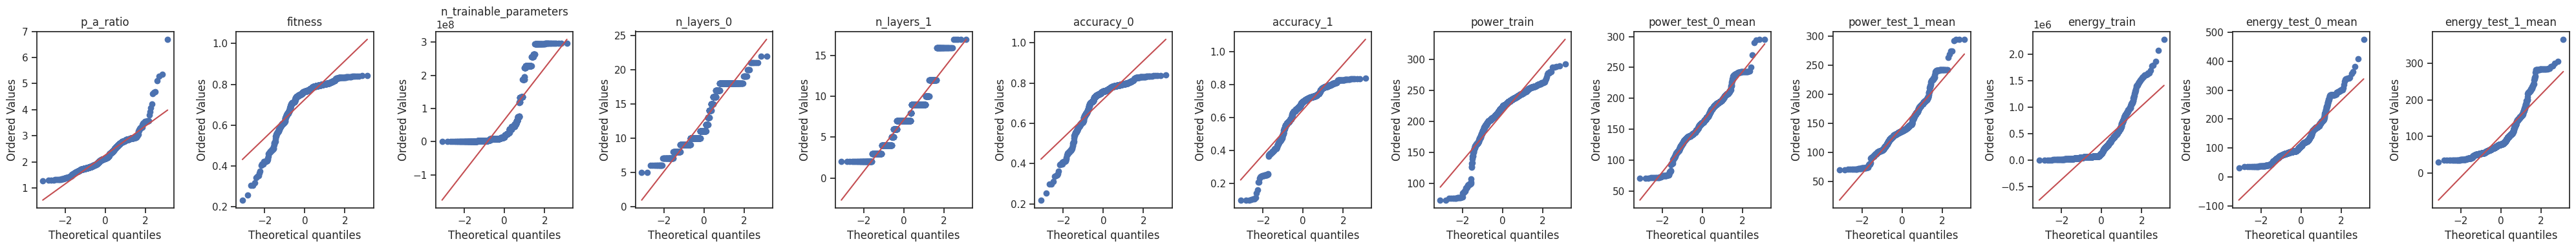

..Follows normal dist (Shapiro-Wilk test, alpha=0.05)
....p_a_ratio                False | 0.90 | 5.17e-22
....fitness                  False | 0.80 | 1.52e-29
....n_trainable_parameters   False | 0.69 | 6.98e-35
....n_layers_0               False | 0.90 | 1.65e-21
....n_layers_1               False | 0.92 | 1.20e-19
....accuracy_0               False | 0.80 | 1.26e-29
....accuracy_1               False | 0.87 | 4.67e-24
....power_train              False | 0.85 | 4.40e-26
....power_test_0_mean        False | 0.98 | 3.29e-07
....power_test_1_mean        False | 0.94 | 4.14e-16
....energy_train             False | 0.76 | 7.49e-32
....energy_test_0_mean       False | 0.88 | 1.62e-23
....energy_test_1_mean       False | 0.82 | 2.22e-28



,p_a_ratio,fitness,n_trainable_parameters,n_layers_0,n_layers_1,accuracy_0,accuracy_1,power_train,power_test_0_mean,power_test_1_mean,energy_train,energy_test_0_mean,energy_test_1_mean
p_a_ratio,1.000000,-0.107908,0.610392,0.278025,-0.056341,-0.093272,-0.150017,0.647312,0.870266,0.519737,0.364287,0.507083,0.218468
fitness,-0.107908,1.000000,-0.070549,0.415386,0.432033,0.999589,0.825955,0.285969,0.263041,0.448181,0.189658,0.431612,0.571697
n_trainable_parameters,0.610392,-0.070549,1.000000,-0.115193,-0.143352,-0.066812,-0.098084,0.455389,0.572284,0.294305,0.388306,0.319382,0.118275
n_layers_0,0.278025,0.415386,-0.115193,1.000000,0.557990,0.419791,0.419667,0.340243,0.360870,0.419474,0.238029,0.518156,0.482575
n_layers_1,-0.056341,0.432033,-0.143352,0.557990,1.000000,0.430228,0.735635,0.123009,0.050146,0.546800,0.087772,0.144577,0.609676
accuracy_0,-0.093272,0.999589,-0.066812,0.419791,0.430228,1.000000,0.823282,0.298153,0.278225,0.457606,0.194484,0.437310,0.573335
accuracy_1,-0.150017,0.825955,-0.098084,0.419667,0.735635,0.823282,1.000000,0.227862,0.157842,0.592108,0.145926,0.325758,0.698275
power_train,0.647312,0.285969,0.455389,0.340243,0.123009,0.298153,0.227862,1.000000,0.772708,0.563188,0.366858,0.479425,0.326867
power_test_0_mean,0.870266,0.263041,0.572284,0.360870,0.050146,0.278225,0.157842,0.772708,1.000000,0.676406,0.432730,0.672424,0.394452
power_test_1_mean,0.519737,0.448181,0.294305,0.419474,0.546800,0.457606,0.592108,0.563188,0.676406,1.000000,0.352631,0.587616,0.793971


,p_a_ratio,fitness,n_trainable_parameters,n_layers_0,n_layers_1,accuracy_0,accuracy_1,power_train,power_test_0_mean,power_test_1_mean,energy_train,energy_test_0_mean,energy_test_1_mean
p_a_ratio,1.000000e+00,3.087370e-03,9.236510e-78,8.854172e-15,1.231670e-01,1.059794e-02,3.708928e-05,2.826880e-90,3.153804e-232,4.001272e-53,5.943335e-25,3.012017e-50,1.483166e-09
fitness,3.087370e-03,1.000000e+00,5.345107e-02,1.201953e-32,1.862427e-35,0.000000e+00,2.252197e-188,1.395251e-15,2.461816e-13,2.459213e-38,1.668745e-07,2.203474e-35,2.651145e-66
n_trainable_parameters,9.236510e-78,5.345107e-02,1.000000e+00,1.577908e-03,8.159203e-05,6.744394e-02,7.184790e-03,1.134433e-39,1.823261e-66,1.881976e-16,2.117254e-28,3.020125e-19,1.174105e-03
n_layers_0,8.854172e-15,1.201953e-32,1.577908e-03,1.000000e+00,1.341878e-62,2.247452e-33,2.356763e-33,8.809603e-22,1.744021e-24,2.537746e-33,4.030278e-11,9.292024e-53,5.230242e-45
n_layers_1,1.231670e-01,1.862427e-35,8.159203e-05,1.341878e-62,1.000000e+00,3.822900e-35,1.146679e-128,7.356390e-04,1.701044e-01,1.062831e-59,1.620019e-02,7.076923e-05,1.555853e-77
accuracy_0,1.059794e-02,0.000000e+00,6.744394e-02,2.247452e-33,3.822900e-35,1.000000e+00,3.905306e-186,7.297456e-17,8.457380e-15,4.337923e-40,7.934583e-08,2.219381e-36,9.307009e-67
accuracy_1,3.708928e-05,2.252197e-188,7.184790e-03,2.356763e-33,1.146679e-128,3.905306e-186,1.000000e+00,2.735288e-10,1.407193e-05,3.739893e-72,6.041832e-05,5.320208e-20,1.041927e-110
power_train,2.826880e-90,1.395251e-15,1.134433e-39,8.809603e-22,7.356390e-04,7.297456e-17,2.735288e-10,1.000000e+00,8.498932e-150,5.537813e-64,2.622112e-25,2.300226e-44,3.916863e-20
power_test_0_mean,3.153804e-232,2.461816e-13,1.823261e-66,1.744021e-24,1.701044e-01,8.457380e-15,1.407193e-05,8.498932e-150,1.000000e+00,1.958542e-101,1.409343e-35,7.849760e-100,2.490593e-29
power_test_1_mean,4.001272e-53,2.459213e-38,1.881976e-16,2.537746e-33,1.062831e-59,4.337923e-40,3.739893e-72,5.537813e-64,1.958542e-101,1.000000e+00,2.215176e-23,7.875378e-71,7.958457e-164


In [9]:
for experiment in EXPERIMENTS:
    print(f"Experiment: {experiment}")
    fig, axes = plt.subplots(1, len(KEYS), figsize=(40, 4))
    flattened_axes = np.ndarray.flatten(axes)

    normal_str = f"..Follows normal dist (Shapiro-Wilk test, alpha={alpha})\n"
    correlation_str = f"..Correlation matrix\n"
    for i, k in enumerate(KEYS):
        if experiment.startswith("DENSER") and k in KEYS_ENERGIZE_TO_DENSER:
            k = KEYS_ENERGIZE_TO_DENSER[k]
        ax = flattened_axes[i]
        k_data = experiments_data[experiment]['data'][k]
        stats.probplot(list(k_data), dist="norm", plot=ax)
        ax.set_title(k)

        # shapiro-wilk test
        stat, p = stats.shapiro(k_data)
        normal = p > alpha
        experiments_data[experiment]['shapiro'][k] = {'stat': stat, 'p': p, 'normal': normal}
        normal_str += f"....{k:25}{colored(normal, 'green' if normal else 'red')} | {stat:.2f} | {p:.2e}\n"

    plt.tight_layout()
    plt.show()

    print(normal_str)

    # correlation coefficients
    keys = list(KEYS)
    if experiment.startswith('DENSER'):
        keys = [KEYS_ENERGIZE_TO_DENSER[k] if k in KEYS_ENERGIZE_TO_DENSER else k for k in keys]

    corr_matrix_spearman_stat = experiments_data[experiment]['data'][keys].corr(method='spearman')
    corr_matrix_spearman_p = experiments_data[experiment]['data'][keys].corr(method=lambda i, j: stats.spearmanr(i, j)[1])

    display(corr_matrix_spearman_stat)
    display(corr_matrix_spearman_p)

In [10]:
# YLIMS_BY_DATASET = {
#     "fashionmnist": {
#         "p_a_ratio": {
#             "lim": (0, 0.1),
#             "loc": "upper right",
#             "ylog": False
#         }
#     }
# }

p_a_ratio


<Figure size 2500x1000 with 0 Axes>

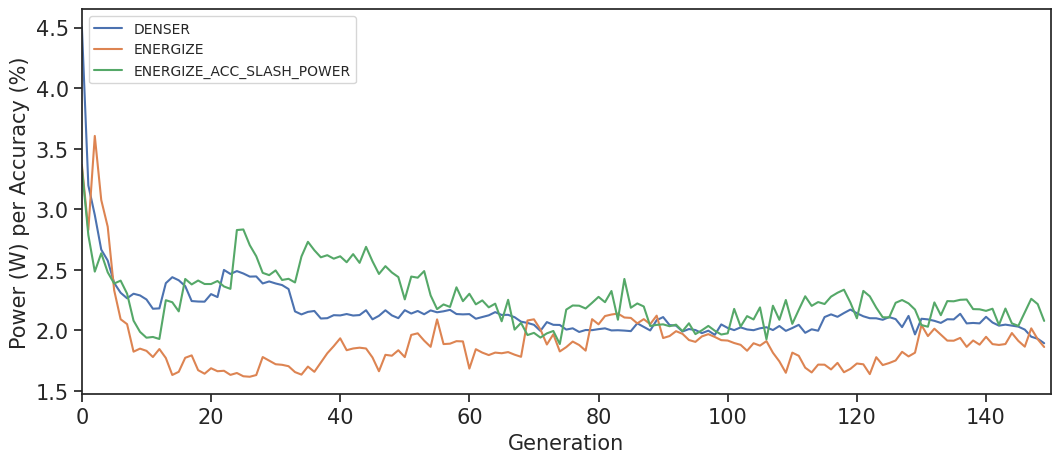

fitness


<Figure size 2500x1000 with 0 Axes>

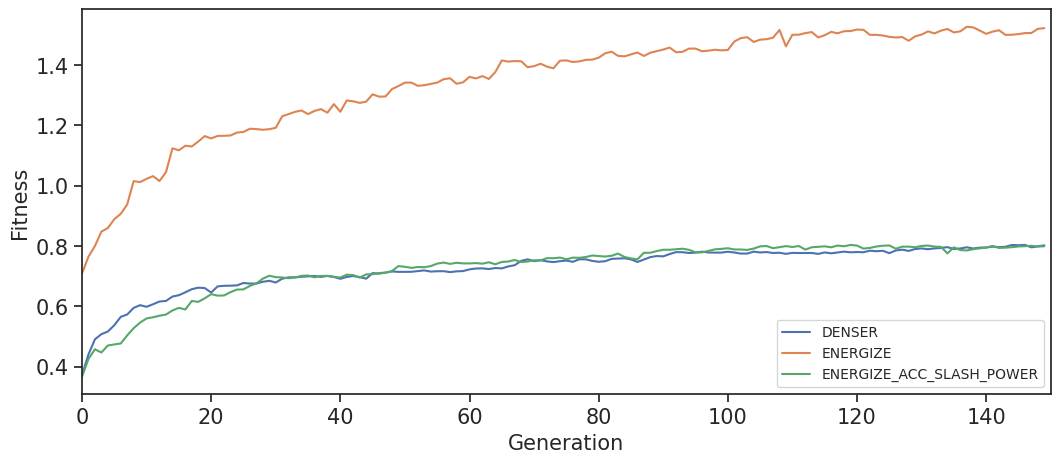

n_trainable_parameters


<Figure size 2500x1000 with 0 Axes>

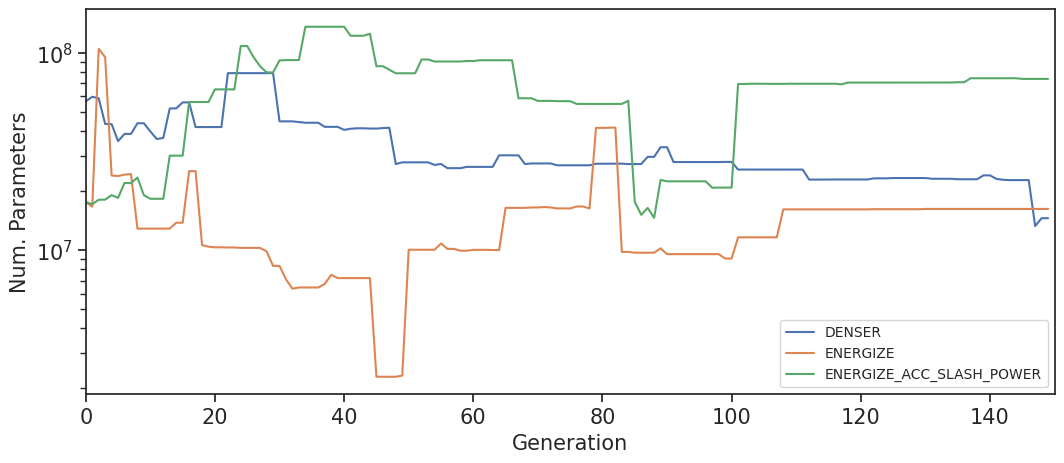

n_layers_0


<Figure size 2500x1000 with 0 Axes>

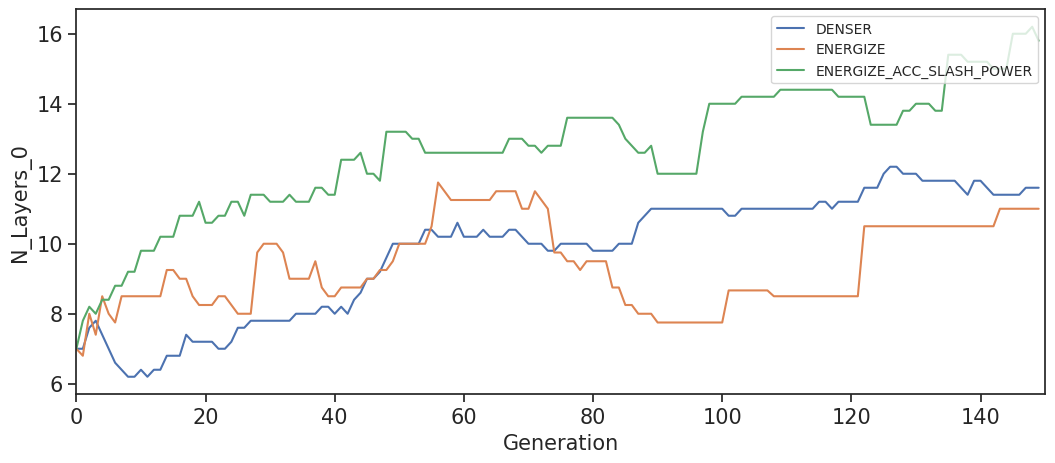

n_layers_1


<Figure size 2500x1000 with 0 Axes>

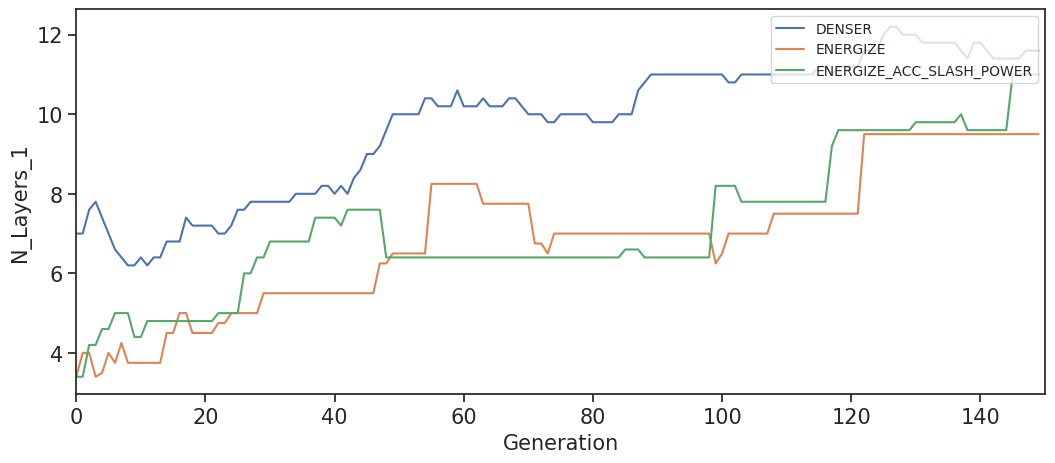

accuracy_0


<Figure size 2500x1000 with 0 Axes>

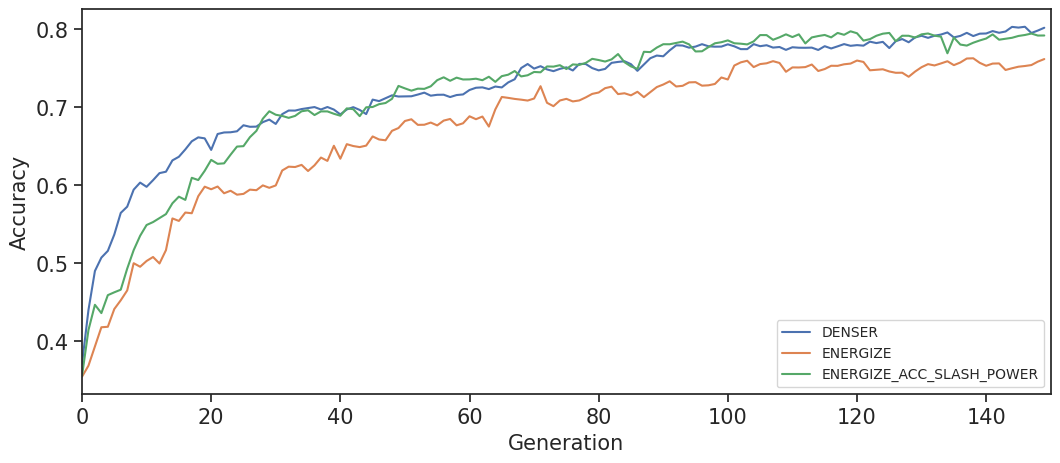

accuracy_1


<Figure size 2500x1000 with 0 Axes>

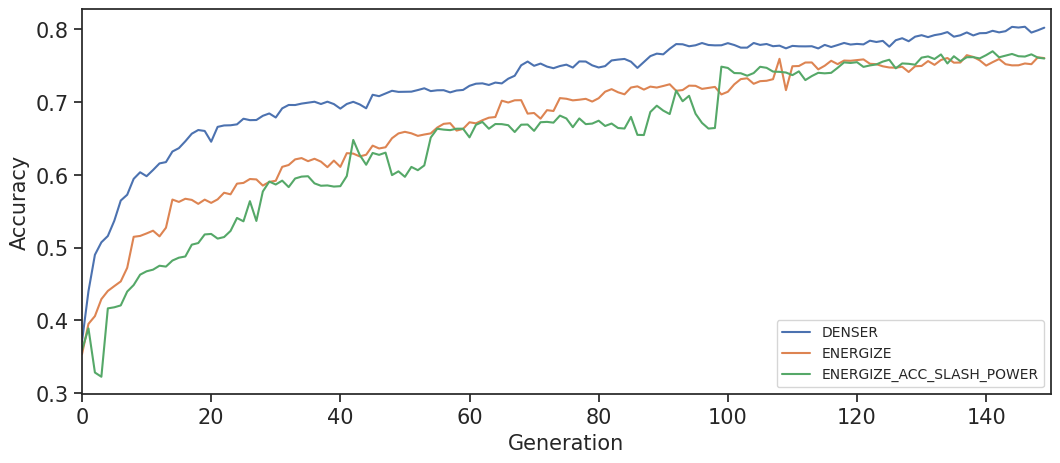

power_train


<Figure size 2500x1000 with 0 Axes>

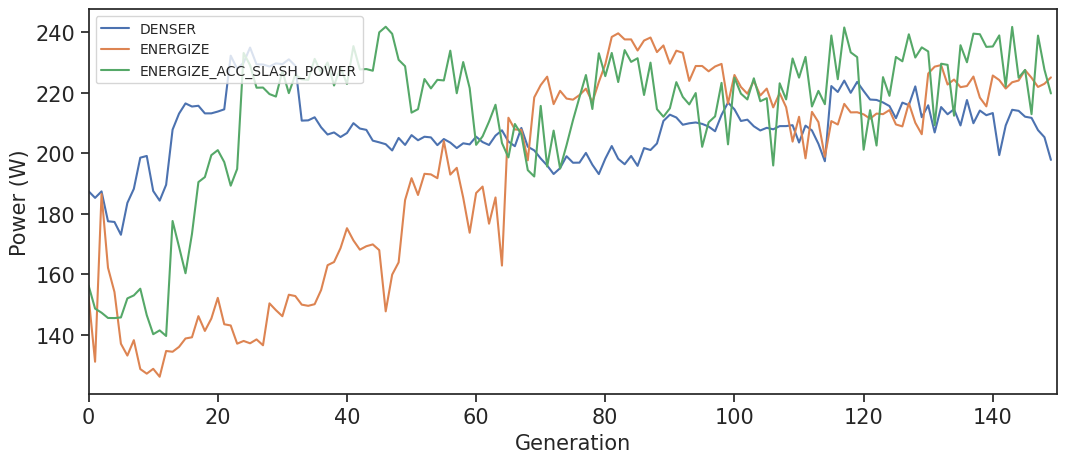

power_test_0_mean


<Figure size 2500x1000 with 0 Axes>

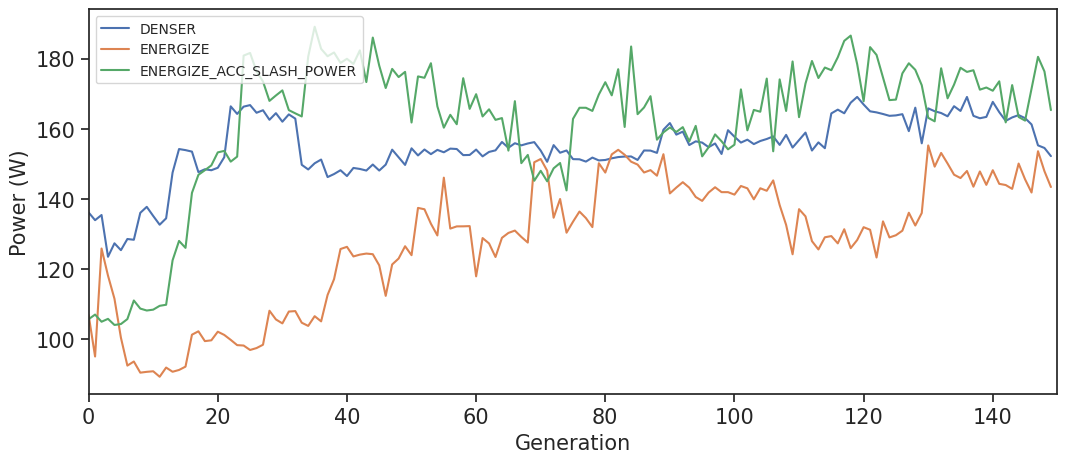

power_test_1_mean


<Figure size 2500x1000 with 0 Axes>

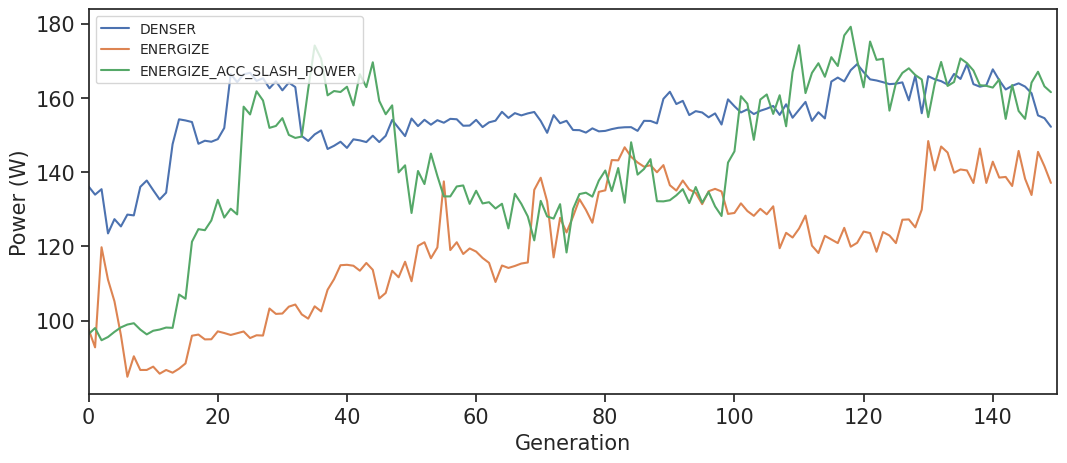

energy_train


<Figure size 2500x1000 with 0 Axes>

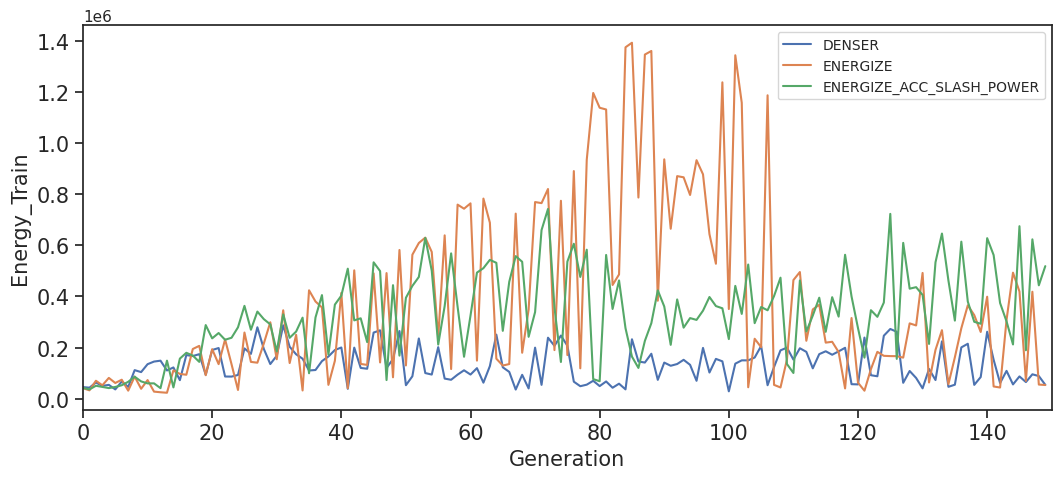

energy_test_0_mean


<Figure size 2500x1000 with 0 Axes>

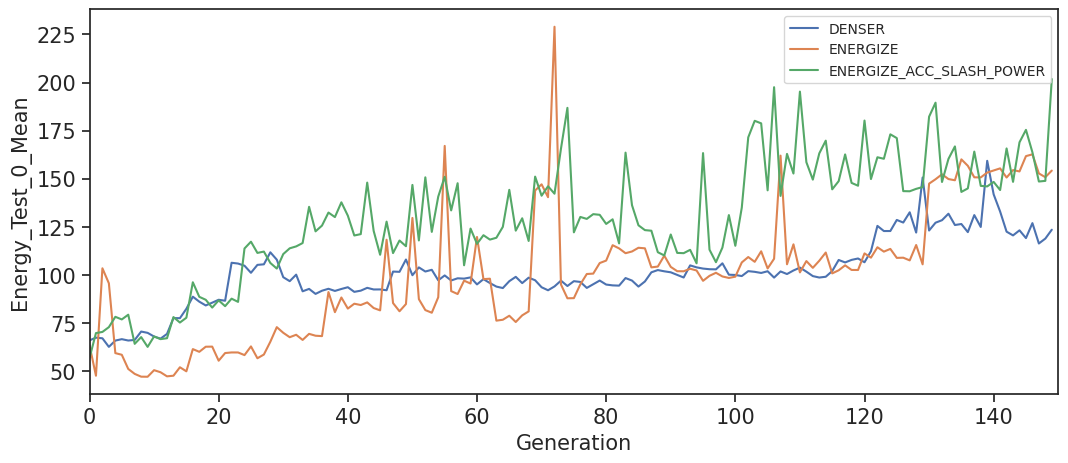

energy_test_1_mean


<Figure size 2500x1000 with 0 Axes>

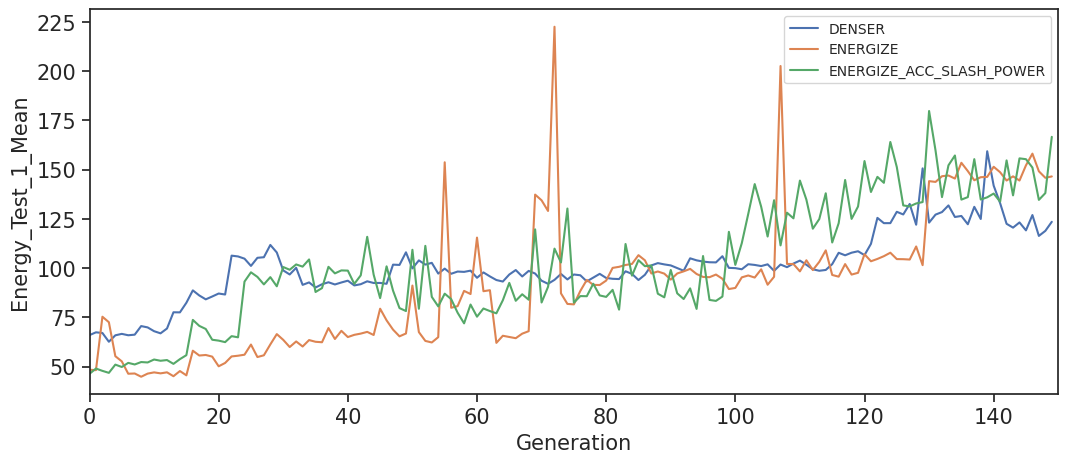

In [17]:
for i, k in enumerate(KEYS):
    plt.figure()
    print(k)
    fig, ax = plt.subplots(figsize=(12.5, 5))
    for experiment in EXPERIMENTS:
        _k = k
        if experiment.startswith('DENSER') and k in KEYS_ENERGIZE_TO_DENSER:
            _k = KEYS_ENERGIZE_TO_DENSER[k]
        sn.lineplot(experiments_data[experiment]['data'], x='gen', y=_k, label=experiment, ax=ax, errorbar=None)

    loc = "upper right"
    if k.startswith('accuracy') or k.startswith('n_train') or k == "fitness":
        loc = "lower right"
    elif k.startswith('power'):
        loc = "upper left"

    if k.startswith('accuracy'):
        ylabel = 'Accuracy'
        # ylim = (0.75, 0.95)
    elif k.startswith('power'):
        ylabel = 'Power (W)'
        # ylim = (75, 260)
    elif k.startswith('n_trainable'):
        ax.set_yscale('log')
        ylabel = 'Num. Parameters'
    elif k == 'p_a_ratio':
        loc = "upper left"
        # ax.set_ylim(0.8, 1.8)
        ylabel = "Power (W) per Accuracy (%)"
        # ax.set_yscale('log')
    else:
        ylabel = k.title()
        ylim = None

    ax.legend(loc=loc, prop={'size': 10})
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    ax.set_xlabel('Generation', fontsize=15)
    ax.set_ylabel(ylabel, fontsize=15)
    # if ylim is not None:
    #     ax.set_ylim(*ylim)
    ax.set_xlim(0, 150)
    plt.show()

Comparison (assumes normal dist is not followed)
1. Kruskal-Wallis
2. if H0 is rejected -> Mann-Whitney with Bonferroni correction

In [12]:
# group by generation and calculate mean
for experiment in EXPERIMENTS:
    keys = list(KEYS)
    if experiment.startswith('DENSER'):
        keys = [KEYS_ENERGIZE_TO_DENSER[k] if k in KEYS_ENERGIZE_TO_DENSER else k for k in keys]
    experiments_data[experiment]['data'] = experiments_data[experiment]['data'][['gen', *keys]].groupby('gen').mean()
    if experiment.startswith('DENSER'):
        experiments_data[experiment]['data'] = experiments_data[experiment]['data'].iloc[:, ~experiments_data[experiment]['data'].columns.duplicated()]

Key: p_a_ratio
..Kruskal-Wallis test (alpha=0.05)
....stat=220.271 and p-value=1.475e-48
....reject H0 -> median is not equal across all groups
..Mann-Whitney U test (alpha=0.05, Bonferroni correction)


,DENSER,ENERGIZE,ENERGIZE_ACC_SLASH_POWER
DENSER,1.000000e+00,4.796738e-33,2.445560e-07
ENERGIZE,4.796738e-33,1.000000e+00,7.873452e-37
ENERGIZE_ACC_SLASH_POWER,2.445560e-07,7.873452e-37,1.000000e+00


<Figure size 2500x1000 with 0 Axes>

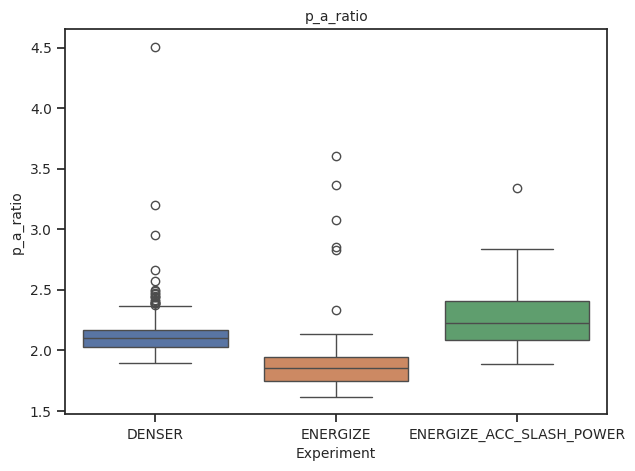

Key: fitness
..Kruskal-Wallis test (alpha=0.05)
....stat=291.588 and p-value=4.813e-64
....reject H0 -> median is not equal across all groups
..Mann-Whitney U test (alpha=0.05, Bonferroni correction)


,DENSER,ENERGIZE,ENERGIZE_ACC_SLASH_POWER
DENSER,1.000000e+00,9.305757e-49,1.977727e-01
ENERGIZE,9.305757e-49,1.000000e+00,1.202486e-48
ENERGIZE_ACC_SLASH_POWER,1.977727e-01,1.202486e-48,1.000000e+00


<Figure size 2500x1000 with 0 Axes>

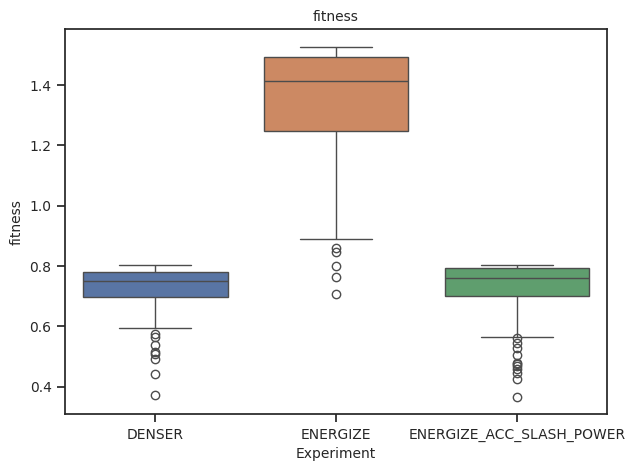

Key: n_trainable_parameters
..Kruskal-Wallis test (alpha=0.05)
....stat=283.944 and p-value=2.200e-62
....reject H0 -> median is not equal across all groups
..Mann-Whitney U test (alpha=0.05, Bonferroni correction)


,DENSER,ENERGIZE,ENERGIZE_ACC_SLASH_POWER
DENSER,1.000000e+00,1.189645e-40,7.150116e-16
ENERGIZE,1.189645e-40,1.000000e+00,2.691214e-44
ENERGIZE_ACC_SLASH_POWER,7.150116e-16,2.691214e-44,1.000000e+00


<Figure size 2500x1000 with 0 Axes>

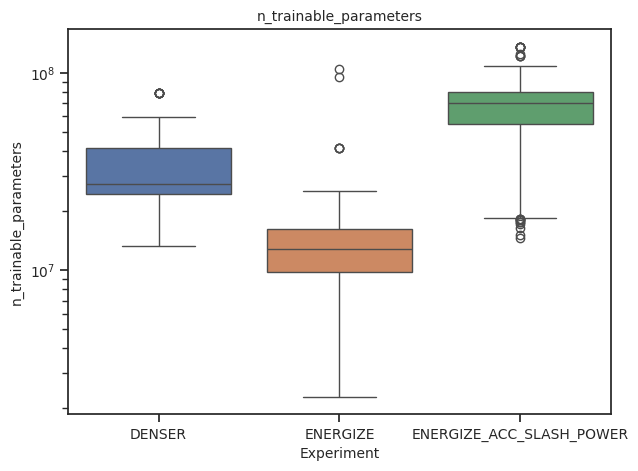

Key: n_layers_0
..Kruskal-Wallis test (alpha=0.05)
....stat=198.805 and p-value=6.762e-44
....reject H0 -> median is not equal across all groups
..Mann-Whitney U test (alpha=0.05, Bonferroni correction)


,DENSER,ENERGIZE,ENERGIZE_ACC_SLASH_POWER
DENSER,1.000000e+00,2.106748e-02,4.272116e-30
ENERGIZE,2.106748e-02,1.000000e+00,4.541582e-36
ENERGIZE_ACC_SLASH_POWER,4.272116e-30,4.541582e-36,1.000000e+00


<Figure size 2500x1000 with 0 Axes>

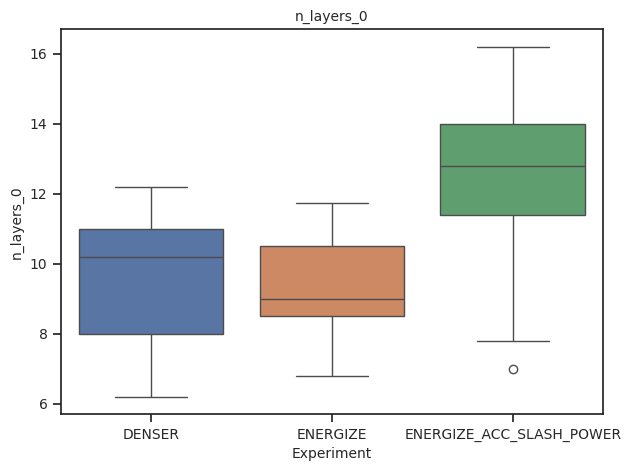

Key: n_layers_1
..Kruskal-Wallis test (alpha=0.05)
....stat=165.389 and p-value=1.220e-36
....reject H0 -> median is not equal across all groups
..Mann-Whitney U test (alpha=0.05, Bonferroni correction)


,DENSER,ENERGIZE,ENERGIZE_ACC_SLASH_POWER
DENSER,1.000000e+00,1.946820e-29,3.362469e-27
ENERGIZE,1.946820e-29,1.000000e+00,1.000000e+00
ENERGIZE_ACC_SLASH_POWER,3.362469e-27,1.000000e+00,1.000000e+00


<Figure size 2500x1000 with 0 Axes>

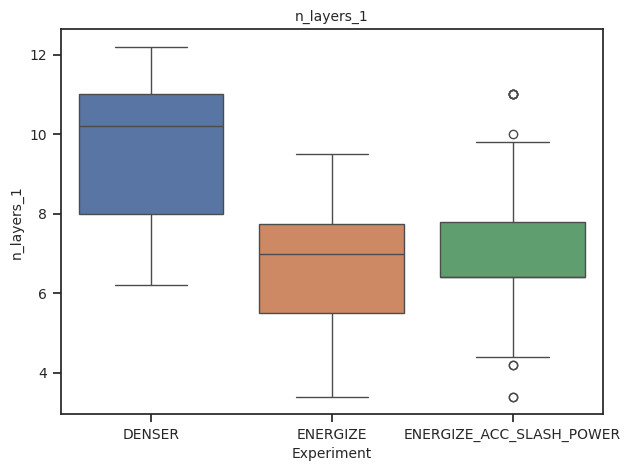

Key: accuracy_0
..Kruskal-Wallis test (alpha=0.05)
....stat=45.358 and p-value=1.415e-10
....reject H0 -> median is not equal across all groups
..Mann-Whitney U test (alpha=0.05, Bonferroni correction)


,DENSER,ENERGIZE,ENERGIZE_ACC_SLASH_POWER
DENSER,1.000000e+00,2.271623e-08,1.000000e+00
ENERGIZE,2.271623e-08,1.000000e+00,1.466504e-08
ENERGIZE_ACC_SLASH_POWER,1.000000e+00,1.466504e-08,1.000000e+00


<Figure size 2500x1000 with 0 Axes>

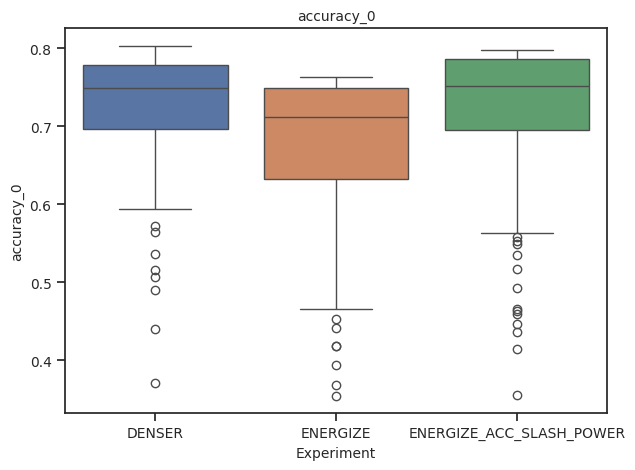

Key: accuracy_1
..Kruskal-Wallis test (alpha=0.05)
....stat=68.763 and p-value=1.170e-15
....reject H0 -> median is not equal across all groups
..Mann-Whitney U test (alpha=0.05, Bonferroni correction)


,DENSER,ENERGIZE,ENERGIZE_ACC_SLASH_POWER
DENSER,1.000000e+00,1.949523e-10,5.382668e-14
ENERGIZE,1.949523e-10,1.000000e+00,6.152250e-01
ENERGIZE_ACC_SLASH_POWER,5.382668e-14,6.152250e-01,1.000000e+00


<Figure size 2500x1000 with 0 Axes>

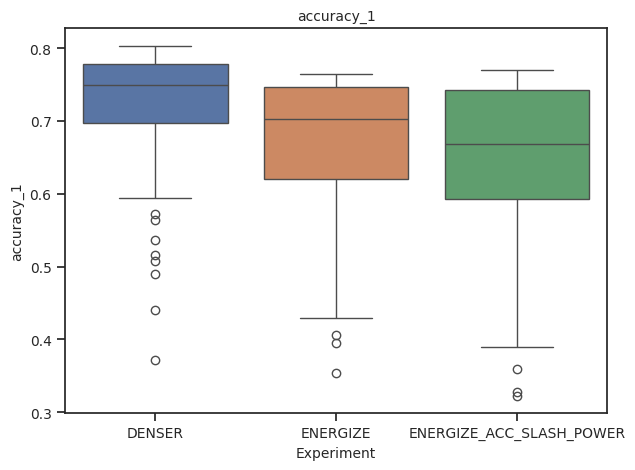

Key: power_train
..Kruskal-Wallis test (alpha=0.05)
....stat=40.501 and p-value=1.605e-09
....reject H0 -> median is not equal across all groups
..Mann-Whitney U test (alpha=0.05, Bonferroni correction)


,DENSER,ENERGIZE,ENERGIZE_ACC_SLASH_POWER
DENSER,1.000000e+00,1.000000e+00,1.551004e-08
ENERGIZE,1.000000e+00,1.000000e+00,7.353105e-07
ENERGIZE_ACC_SLASH_POWER,1.551004e-08,7.353105e-07,1.000000e+00


<Figure size 2500x1000 with 0 Axes>

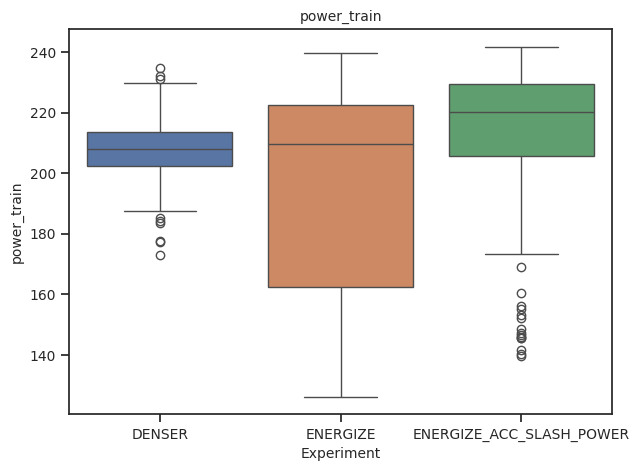

Key: power_test_0_mean
..Kruskal-Wallis test (alpha=0.05)
....stat=229.310 and p-value=1.607e-50
....reject H0 -> median is not equal across all groups
..Mann-Whitney U test (alpha=0.05, Bonferroni correction)


,DENSER,ENERGIZE,ENERGIZE_ACC_SLASH_POWER
DENSER,1.000000e+00,3.407733e-38,1.763856e-11
ENERGIZE,3.407733e-38,1.000000e+00,2.238940e-33
ENERGIZE_ACC_SLASH_POWER,1.763856e-11,2.238940e-33,1.000000e+00


<Figure size 2500x1000 with 0 Axes>

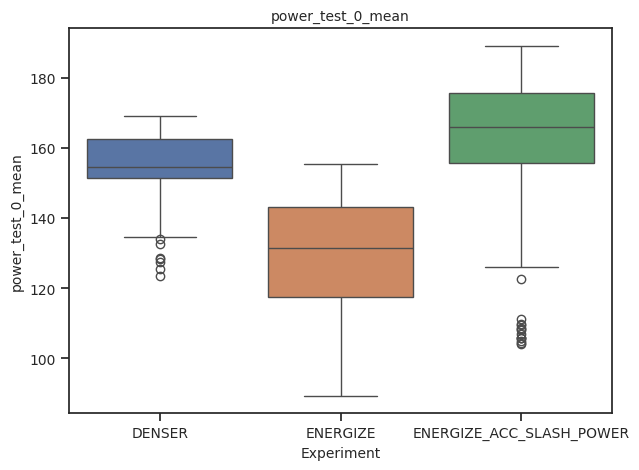

Key: power_test_1_mean
..Kruskal-Wallis test (alpha=0.05)
....stat=195.518 and p-value=3.499e-43
....reject H0 -> median is not equal across all groups
..Mann-Whitney U test (alpha=0.05, Bonferroni correction)


,DENSER,ENERGIZE,ENERGIZE_ACC_SLASH_POWER
DENSER,1.000000e+00,3.337866e-45,2.403275e-03
ENERGIZE,3.337866e-45,1.000000e+00,5.230841e-19
ENERGIZE_ACC_SLASH_POWER,2.403275e-03,5.230841e-19,1.000000e+00


<Figure size 2500x1000 with 0 Axes>

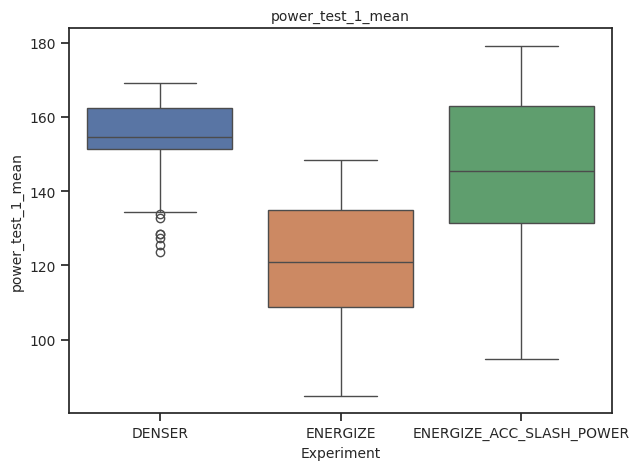

Key: energy_train
..Kruskal-Wallis test (alpha=0.05)
....stat=97.753 and p-value=5.933e-22
....reject H0 -> median is not equal across all groups
..Mann-Whitney U test (alpha=0.05, Bonferroni correction)


,DENSER,ENERGIZE,ENERGIZE_ACC_SLASH_POWER
DENSER,1.000000e+00,1.546440e-09,5.278669e-25
ENERGIZE,1.546440e-09,1.000000e+00,5.514252e-01
ENERGIZE_ACC_SLASH_POWER,5.278669e-25,5.514252e-01,1.000000e+00


<Figure size 2500x1000 with 0 Axes>

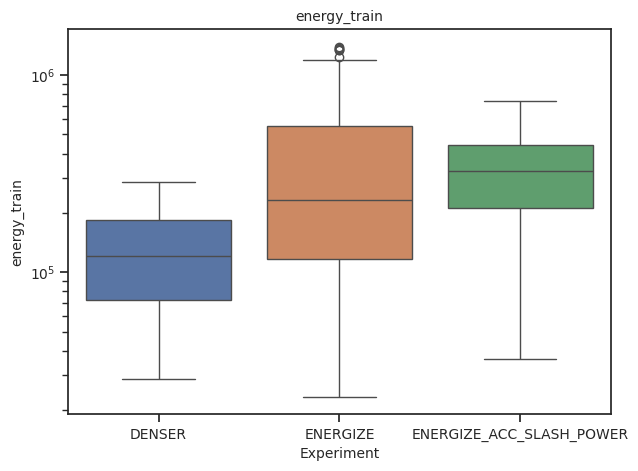

Key: energy_test_0_mean
..Kruskal-Wallis test (alpha=0.05)
....stat=89.586 and p-value=3.521e-20
....reject H0 -> median is not equal across all groups
..Mann-Whitney U test (alpha=0.05, Bonferroni correction)


,DENSER,ENERGIZE,ENERGIZE_ACC_SLASH_POWER
DENSER,1.000000e+00,1.000000e+00,5.420737e-18
ENERGIZE,1.000000e+00,1.000000e+00,7.932037e-14
ENERGIZE_ACC_SLASH_POWER,5.420737e-18,7.932037e-14,1.000000e+00


<Figure size 2500x1000 with 0 Axes>

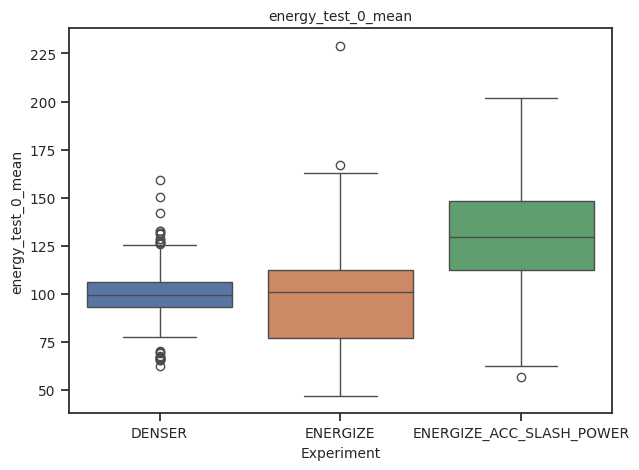

Key: energy_test_1_mean
..Kruskal-Wallis test (alpha=0.05)
....stat=16.694 and p-value=2.372e-04
....reject H0 -> median is not equal across all groups
..Mann-Whitney U test (alpha=0.05, Bonferroni correction)


,DENSER,ENERGIZE,ENERGIZE_ACC_SLASH_POWER
DENSER,1.000000,0.000087,1.000000
ENERGIZE,0.000087,1.000000,0.021986
ENERGIZE_ACC_SLASH_POWER,1.000000,0.021986,1.000000


<Figure size 2500x1000 with 0 Axes>

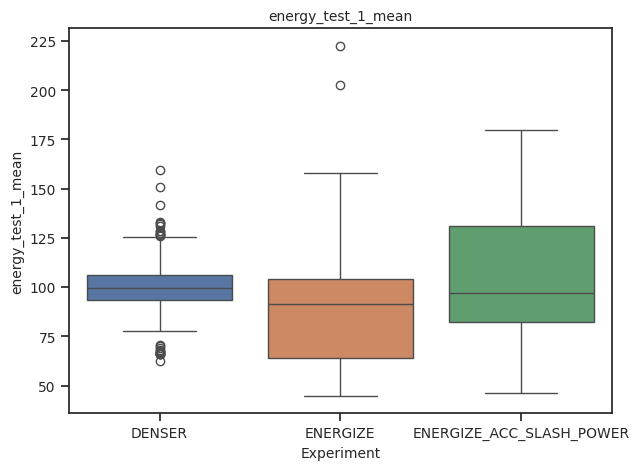

In [13]:
for i, k in enumerate(KEYS):
    print(f"Key: {k}")
    plt.figure()
    data = {
        experiment: experiments_data[experiment]['data'][KEYS_ENERGIZE_TO_DENSER[k] if experiment.startswith('DENSER') and k in KEYS_ENERGIZE_TO_DENSER else k] for experiment in EXPERIMENTS
    }
    fig, ax = plt.subplots(figsize=(7, 5))
    sn.boxplot(data, ax=ax)
    if k.startswith('n_trainable') or k == 'energy_train':
        ax.set_yscale('log')
    ax.set_title(k, fontsize=10)
    ax.set_xlabel('Experiment', fontsize=10)
    ax.set_ylabel(k, fontsize=10)
    ax.tick_params(axis='both', which='major', labelsize=10)

    kruskal_test = stats.kruskal(*data.values())
    print(f"..Kruskal-Wallis test (alpha={alpha})")
    print(f"....stat={kruskal_test.statistic:.3f} and p-value={kruskal_test.pvalue:.3e}")
    if kruskal_test.pvalue >= alpha:
        print("....accept H0 -> median is equal across all groups")
    else:
        print("....reject H0 -> median is not equal across all groups")
        print(f"..Mann-Whitney U test (alpha={alpha}, Bonferroni correction)")
        data_df = pd.DataFrame({
            "group": [exp for exp in EXPERIMENTS for _ in range(len(data[exp]))],
            "value": [v for exp in EXPERIMENTS for v in data[exp]]
        })
        posthoc_df = sp.posthoc_mannwhitney(data_df, group_col="group", val_col="value", p_adjust="bonferroni")
        display(posthoc_df)
    plt.show()

In [14]:
table_rows = []

# for key in KEYS:
for key in ['p_a_ratio', 'accuracy_0', 'power_test_0_mean']:
    for experiment in EXPERIMENTS:
        _key = key
        if experiment.startswith('DENSER') and key in KEYS_ENERGIZE_TO_DENSER:
            _key = KEYS_ENERGIZE_TO_DENSER[key]
        d = experiments_data[experiment]['data'][_key]
        row = {
            'Key': _key,
            'Experiment': experiment,
            'Mean': f"{d.mean():.3f}",
            'Std': f"{d.std():.3f}",
            'Median': f"{d.median():.3f}",
            'Min': f"{d.min():.3f}",
            'Max': f"{d.max():.3f}"
        }
        table_rows.append(row)

df = pd.DataFrame(table_rows)
display(df)

,Key,Experiment,Mean,Std,Median,Min,Max
0,p_a_ratio,DENSER,2.159,0.263,2.105,1.895,4.508
1,p_a_ratio,ENERGIZE,1.895,0.276,1.854,1.618,3.607
2,p_a_ratio,ENERGIZE_ACC_SLASH_POWER,2.264,0.228,2.228,1.888,3.344
3,accuracy,DENSER,0.726,0.075,0.750,0.371,0.803
4,accuracy_0,ENERGIZE,0.677,0.092,0.712,0.355,0.763
5,accuracy_0,ENERGIZE_ACC_SLASH_POWER,0.720,0.093,0.752,0.356,0.797
6,power_test_mean,DENSER,154.594,9.163,154.500,123.509,169.089
7,power_test_0_mean,ENERGIZE,127.995,18.470,131.286,89.296,155.263
8,power_test_0_mean,ENERGIZE_ACC_SLASH_POWER,161.627,20.510,165.998,104.063,189.102


In [15]:
from matplotlib import axis
import pandas as pd

table_rows = []

# for key in KEYS:
for key in ['p_a_ratio', 'accuracy_0', 'power_test_0_mean']:
    for experiment in EXPERIMENTS:
        _key = key
        if experiment.startswith('DENSER') and key in KEYS_ENERGIZE_TO_DENSER:
            _key = KEYS_ENERGIZE_TO_DENSER[key]
        d = experiments_data[experiment]['data']
        best_idx = d['fitness'].idxmax()
        d = d.loc[best_idx]
        row = {
            'Key': _key,
            'Experiment': experiment,
            'Value': d[_key],
        }
        table_rows.append(row)

df = pd.DataFrame(table_rows)
pd.set_option('display.float_format', lambda x: f"{x:.4f}")
display(df)

# best_indices = data.groupby(['run', 'gen'])['fitness'].idxmax()
# best_rows_df = data.loc[best_indices]
# data = best_rows_df.reset_index(drop=True)
# data.head()

,Key,Experiment,Value
0,p_a_ratio,DENSER,2.0069
1,p_a_ratio,ENERGIZE,1.8644
2,p_a_ratio,ENERGIZE_ACC_SLASH_POWER,2.2302
3,accuracy,DENSER,0.8033
4,accuracy_0,ENERGIZE,0.7626
5,accuracy_0,ENERGIZE_ACC_SLASH_POWER,0.7975
6,power_test_mean,DENSER,161.2446
7,power_test_0_mean,ENERGIZE,143.4907
8,power_test_0_mean,ENERGIZE_ACC_SLASH_POWER,178.4494


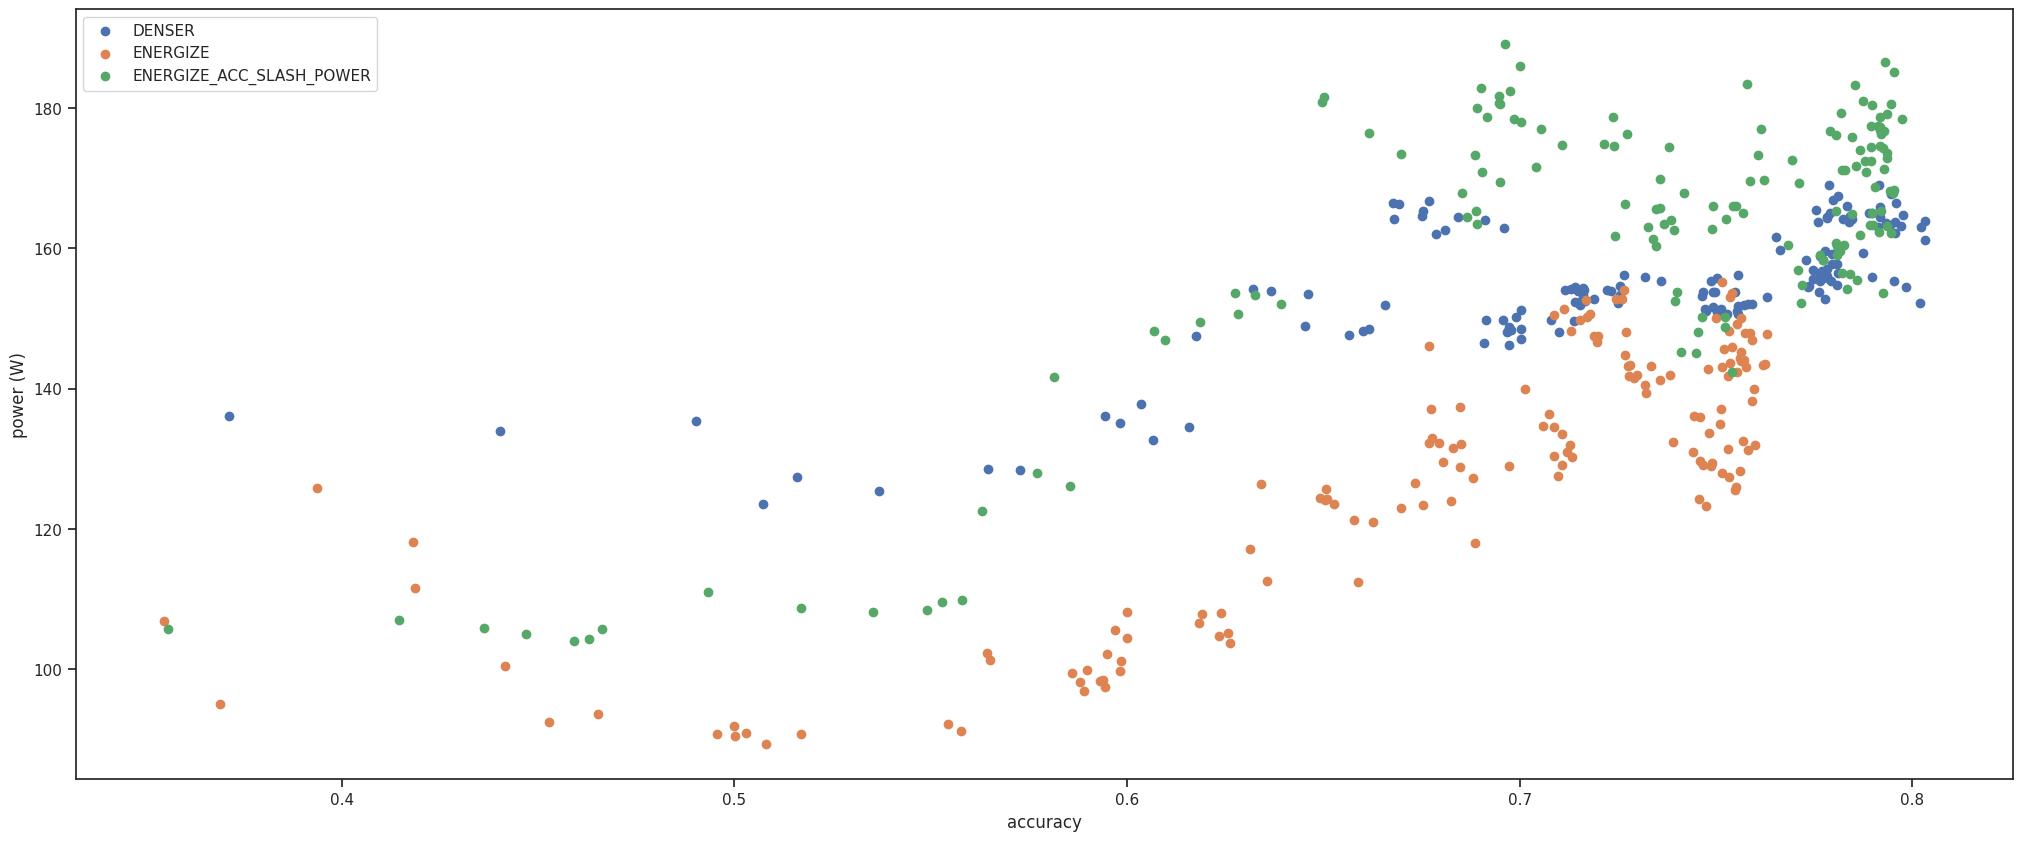

In [16]:
# Y = 'n_trainable_parameters'
# Y = 'n_layers_0'
Y = 'power_test_0_mean'

for exp in EXPERIMENTS:
    k = 'accuracy' if exp.startswith('DENSER') else 'accuracy_0'
    y = Y
    if exp.startswith('DENSER'):
        if Y == 'n_layers_0':
            y = 'n_layers'
        elif Y == 'power_test_0_mean':
            y = 'power_test_mean'
    plt.scatter(experiments_data[exp]['data'][k], experiments_data[exp]['data'][y], label=exp)
    plt.legend()
    plt.xlabel('accuracy')
    plt.ylabel('power (W)')
    # plt.ylabel('n_trainable_parameters')
    # plt.ylabel('n_layers_0')
    # plt.yscale('log')